## Microlensing phenomenon
When a compact object passes close to the line of sight of a distant source, its gravitational field bends the source’s light.  
This produces a temporary **magnification of the source brightness**. 
No change in the source color (achromaticity), in the simplest case


The **characteristic light curve** that depends on the geometry of the event  
  

#### Microlensing system parameters
Microlensing depends on geometry and relative motion. These define the physical configuration of the lens–source system:

- **Relative distances**: observer–lens–source geometry. ($D_{LS}$, $D_{S}$, $D_{S}$)
- **Proper motion** ($ \mu_{rel} $): relative transverse motion between lens and source.  
- **Lens mass** ($M$): sets the Einstein radius and event timescale.  
- **Source radius**: relevant for finite-source effects.
- **Impact parameter**: closest approach between lens and source in angular units  
- **Blending**: extra flux from nearby unresolved stars  

#### Microlensing light curve parameters
These control the shape of the observed magnification curve:

- **$t_0$** – time of closest approach.  
- **$u_0$** – minimum impact parameter (in units of Einstein radius).  
- **$t_E$** – Einstein timescale of the event.  
- **$F_s$** – source flux.  
- **$F_b$** – blend or background flux.  
- **$\rho$** – source radius normalized by the Einstein radius (for finite-source effects).


## Paczyński Model: Microlensing equations 

Standard **point-source, point-lens** microlensing event.  

The **angular Einstein radius** sets the characteristic scale of the event:


$\theta_E = \sqrt{  \frac{4GM}{c^2} \frac{D_{LS}}{D_L D_S}  }$


The **Einstein timescale** describes how long it takes the source-lens separation to change by one Einstein radius:

$
t_E = \frac{\theta_E}{\mu_{rel}},
$

The time-dependent angular separation between source and lens (in units of $\theta_E$) is **impact parameter**:

$
u(t) = \sqrt{ u_0^2 + \left( \frac{t - t_0}{t_E} \right)^2 },
$

where the maximum magnification happens at the maximun approximation instant $ t_0 $

**Paczyński Magnification**: The total magnification for a point-source, point-lens is:

$
A(u) = \frac{u^2 + 2}{u \sqrt{u^2 + 4}}.
$

Light curve: The observed flux includes **source flux** and possible **blend flux** from unresolved stars:

$
F(t) = F_s \, A(u(t)) + F_b,
$

where:

- $F_s$: intrinsic source flux  
- $F_b$: blended flux contribution  



Einstein radius (mas): 0.031
Einstein timescale (days): 5.7


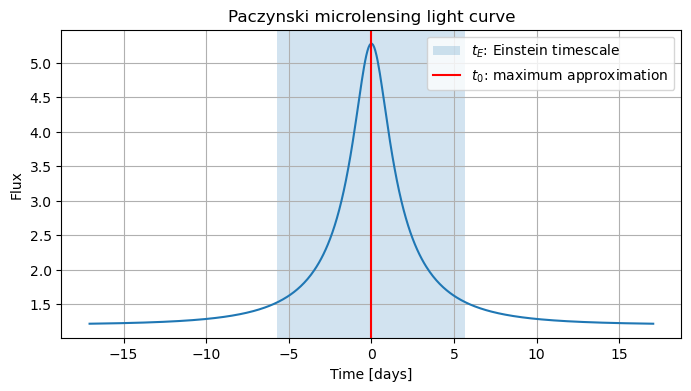

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Set microlensing system parameters

lens_mass = 5        # lens mass in solar masses
mu_rel = 2.0           # relative proper motion (mas/yr)
D_L = 6.0e3            # lens distance in pc
D_S = 7.0e3            # source distance in pc
t0 = 0.0               # time of maximum approximation [days]
u0 = 0.2               # minimum impact parameter
F_s = 1.0              # source flux (arbitrary units)
F_b = 0.2              # blend flux

# Convert system parameters into light-curve parameters

def einstein_radius(mass, D_L, D_S):
    """
    Compute angular Einstein radius in milliarcseconds (mas).
    mass in solar masses, distances in pc.
    """
    k = 8.144  # mas * M_sun^-1 * (pc)^-1
    return np.sqrt(k * mass * (1/D_L - 1/D_S))

def einstein_timescale(theta_E, mu_rel):
    """Return Einstein timescale in days."""
    # mu_rel is mas/yr; convert to mas/day
    mu_day = mu_rel / 365.25
    return theta_E / mu_day

theta_E = einstein_radius(lens_mass, D_L, D_S)  # mas
t_E = einstein_timescale(theta_E, mu_rel)       # days

print(f"Einstein radius (mas): {theta_E:.3f}")
print(f"Einstein timescale (days): {t_E:.1f}")

def magnification(u):
    """Paczynski magnification for a point-source, point-lens."""
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

def microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b):
    """Return total flux F(t) = F_s * A(u) + F_b."""
    u = np.sqrt(u0**2 + ((t - t0) / t_E)**2)
    A = magnification(u)
    return F_s * A + F_b

t = np.linspace(-3*t_E, 3*t_E, 500)
F_t = microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b)


plt.figure(figsize=(8,4))
plt.plot(t, F_t)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.axvspan(t0 - t_E, t0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.axvline(t0, color ="r", label="$t_0$: maximum approximation")
plt.title("Paczynski microlensing light curve")
plt.grid(True)
plt.legend()
plt.show()


## Image-Based Simulations

**Note on blending:**

In analytic models, the blend flux $F_b$ represents extra light from unresolved nearby stars. But when the microlensed source is **injected directly into real images**, blending is **automatic**:

- The image already contains sky background and neighboring stars.  
- The measured flux naturally includes all local contamination.  

Thus, in this simulation we set $F_b = 0 \Rightarrow F(t) = F_s\, A(u(t))$ with blending handled by the image itself.



1. Sources: AstroDataLab - TRILEGAL-NOIRLab
2. Present paczyski
3. microlensing parameters: genulens,
4. microlensing light curve (high cadence, no noise): pyLIMA
5. obtain cadence to create the micronlensing light curve with realistic cadence (yet, without errors)
6. Filters (cuts)
7. Plots and important results
8. Present ulens_lsst

### 1. Sources: LSST's stellar distribution
[AstroDataLab - TRILEGAL-NOIRLab](https://datalab.noirlab.edu/data/lsst-sim) 
The LSST SIM tables contain a large simulation, based on the TRILEGAL code, of the stars to be observed by the Vera C. Rubin Observatory Legacy Survey of Space and Time (LSST). TRILEGAL uses databases of stellar evolutionary tracks, synthetic spectra, and pulsation models, added to simple prescriptions for the stellar density and star formation histories of the main structures of the Galaxy, to generate mock stellar samples through a population synthesis approach.

LSST SIM provides tables containing a complete simulation for single stars in the Milky Way and Magellanic Clouds down to a depth of r=27.5 mag, equivalent to the co-added depth from the Wide-Fast-Deep portion of the LSST survey. LSST SIM also provides a table for a subset of the anticipated binary systems, including interacting ones, as derived with the BinaPSE module of TRILEGAL.


In [17]:
# To install Data Lab and query using Python un-comment and run the following:
# !pip install --upgrade astro-datalab

Here is a function to easy create the query to reatrieve the needed data.

In [47]:
from dl import queryClient as qc

def sky_catalog_query(catalog, columns, regions, conditions=None, language = "sql"):
    """
    Generate a query for astronomical catalogs based on spatial regions and filters.

    Parameters
    ----------
    catalog : str
        Name of the catalog table.
    columns : list of str
        List of column names to select.
    region : tuple
        (ra, dec, radius) in degrees.
    conditions : list of str
        List of additional filter conditions (e.g., 'mag < 20').
    language : str, optional
        Query language: 'sql' (uses q3c_radial_query) or 'adql' (uses CONTAINS + CIRCLE) (default: 'sql').
    """
    ra, dec, radius = region
    if language == "sql":
        # SQL version with q3c_radial_query
        spatial_clause = f"q3c_radial_query(ra, dec, {ra}, {dec}, {radius})"
    elif language == "adql":
        # ADQL version with CONTAINS + CIRCLE
        spatial_clause = f"CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius}))=1"
    else:
        raise ValueError("language must be 'sql' or 'adql'")

    # Additional conditions
    if conditions is not None:
        filter_part = " AND ".join(conditions)
    if conditions and spatial_clause:
        where_statement = f"({spatial_part}) AND ({filter_part})"
    elif spatial_clause:
        where_statement = spatial_clause
    elif conditions:
        where_statement = filter_part
    else:
        where_statement = "1=1"

    query = f"""
    SELECT {', '.join(columns)}
    FROM {catalog}
    WHERE {where_statement}
    """
    return query

We will query all sources within a radius of 0.5 degrees centered on (62,-34) and selected columns (more details about this dataset columns [here](https://datalab.noirlab.edu/data-explorer?showTable=lsst_sim.simdr2))

In [37]:
catalog = "lsst_sim.simdr2" # "lsst_sim.simdr2_binary"
region = (62, -34, 0.5) # degrees
columns = ["ra", "dec", "logl", "logte", 
           "umag", "gmag", "rmag", "imag", "zmag", "ymag", "gc", "label"]
# condition = 
query = sky_catalog_query(catalog, columns, region,  language="sql")
print(query)
try:
    res = qc.query(sql=query, fmt="table")
    df = res.to_pandas()
except Exception as e:
    print(str(e))



    SELECT ra, dec, logl, logte, umag, gmag, rmag, imag, zmag, ymag, gc, label
    FROM lsst_sim.simdr2
    WHERE q3c_radial_query(ra, dec, 62, -34, 0.5)
    


In [38]:
df

,ra,dec,logl,logte,umag,gmag,rmag,imag,zmag,ymag,gc,label
0,61.623969,-34.390371,-2.277,3.5828,31.061,28.505,27.199,26.631,26.354,26.205,3,1
1,61.601897,-34.375096,-0.378,3.7581,23.720,22.821,22.425,22.280,22.236,22.225,3,1
2,61.600147,-34.367165,-1.742,3.6344,30.052,28.153,27.232,26.831,26.638,26.534,3,1
3,61.598361,-34.365108,-2.135,3.5312,28.739,25.816,24.401,23.393,22.906,22.687,2,1
4,61.605346,-34.368540,-1.049,3.6648,27.603,25.804,25.010,24.693,24.548,24.464,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
20552,62.327281,-33.584432,-0.697,3.7139,28.755,27.502,26.939,26.717,26.628,26.585,3,1
20553,62.327096,-33.583170,-0.271,3.7656,28.014,27.080,26.700,26.570,26.536,26.527,3,1
20554,62.331486,-33.584130,-1.311,3.6616,27.631,26.016,25.234,24.893,24.735,24.653,3,1
20555,62.350772,-33.597834,-0.332,3.7666,25.675,24.859,24.495,24.360,24.320,24.312,3,1


To vis

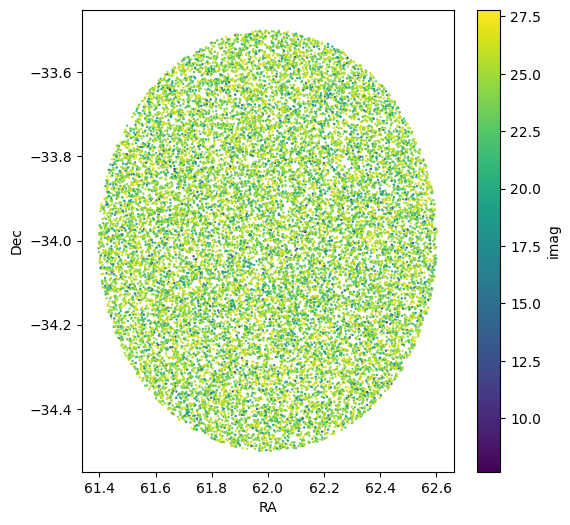

In [46]:
column = "imag"

plt.figure(figsize=(6,6))
sc = plt.scatter(
    df["ra"],
    df["dec"],
    s=0.5,
    c=df[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


* "gc": Galactic component, thin disk=1, thick disk=2, halo=3, bulge=4, MCs=5
* "label": Evolutionary phase, PMS=0, MS=1, SGB=2, RGB=3, CHeB=4,5,6, EAGB=7, TPAGB=8, PAGB+WD=9

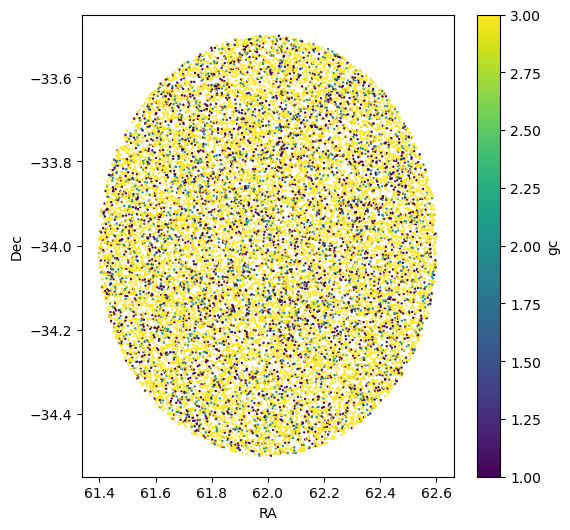

In [44]:
column = "gc"

plt.figure(figsize=(6,6))
sc = plt.scatter(
    df["ra"],
    df["dec"],
    s=0.5,
    c=df[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


In [45]:
df["gc"].value_counts()

gc
3    15045
1     3405
2     2107
Name: count, dtype: int64